# Dividend-Growth — do consistent raisers outperform?
### Annual dividend-growth screen vs equal-weight large-caps, tested honestly

![Signal: WEAK](https://img.shields.io/badge/Signal-WEAK-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![vs_EW%3F: No_Edge](https://img.shields.io/badge/vs_EW%3F-No--Edge-8b949e?style=flat-square)

A cornerstone of retail investing: stocks that *consistently raise* their dividends year after year signal quality, capital discipline, and management confidence — so they should deliver superior long-run returns. The Dividend Aristocrats brand, NOBL ETF, and thousands of YouTube videos sell this idea daily. But when we test it honestly against an equal-weight basket of the same universe, with the survivorship bias named rather than hidden, do the growers actually outperform?

> **This is the plain-language layer.** For the t-stats, bootstrap intervals and multiple-comparisons detail, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_growth import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
_SENTINEL = os.path.join(CACHE_DIR, "dg_AAPL_px.parquet")
HAVE_REAL = os.path.exists(_SENTINEL)

if HAVE_REAL:
    PANEL = data.load_real_panel(fetch=False, cache_dir=CACHE_DIR)
else:
    PANEL = None

print("real data cache present:", HAVE_REAL)


real data cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do growers outperform the equal-weight basket? | **Barely, and not significantly.** Grower mean +12.8%/yr vs EW +13.6%/yr — growers actually **lag** by 0.7%/yr (HAC *t* = -1.51). |
| Is it a 'quality' premium? | The narrative sounds right, but the numbers don't support a meaningful spread. Both arms are near the same Sharpe. |
| What about high-yield non-growers (the Dogs)? | They have a noisier profile and no significant spread over the basket. |
| Could you trade it? | **No.** Survivorship bias flatters the whole basket; annual rebalance costs eat thin spreads; the screen is in the public domain. |

> The 'dividend growth premium' is a story about *quality* — but once you look at the full equal-weight universe of the same survivors, the grower filter adds nothing measurable.

## 1 · The claim

> *'Companies that raise their dividend every year are high-quality businesses with predictable earnings, disciplined management, and durable competitive advantages. Buy the dividend growers and hold them — they will outperform the broad market and beat the high-yielders who are not growing.'*

It's compelling intuition: a company that raises its dividend signals it expects higher future cash flows. The Dividend Aristocrats (25+ consecutive years of raises), Dividend Kings (50+ years), and ETFs like NOBL are built on exactly this idea. The literature (Litzenberger & Ramaswamy 1979, Arnott & Asness 2003) suggests some link between dividend policy and future returns.

We test the sharpest version of the claim: among a fixed basket of 40 large-cap payers **(survivorship-biased — named, not hidden)**, do names with **3+ consecutive years of dividend raises** earn meaningfully higher next-year total returns than the full equal-weight basket and than high-yield non-growers?

## 2 · So what?

If the grower premium is real and large, it's a simple annual rebalance that anyone can implement: screen for consecutive raisers, buy equal-weight, revisit each December. Hundreds of billions of dollars in ETFs and mutual funds run essentially this strategy. If the premium is not there — or only exists because the basket itself is full of survivors — then the 'dividend growth' brand is a quality story with no incremental return over a plain equal-weight basket of the same names.

## 3 · How would we even know?

Two things keep us honest:

1. **An unconditional equal-weight baseline.** If we compare growers to 'the market', we conflate the quality tilt of our universe (40 surviving dividend payers) with the grower filter. The right question is: within this universe, do the growers beat the others? So the baseline is the equal-weight average of all 40 names — any spread over it is attributable to the growth screen, not the universe selection.
2. **Name the survivorship bias.** The 40 names are chosen because they are large-cap dividend payers as of 2026. Companies that cut dividends or were acquired/delisted are absent. The whole basket is 'pre-filtered for success' — the grower screen inside it is a second filter, and any outperformance it shows must be weighed against the base-rate bias of the full basket.

We use a **synthetic positive control** to confirm the engine works: when a real premium is planted in fake data, the screen finds it. If the real tape returns nothing, it is the market speaking, not the method failing.

## 4 · The teardown

**First: does the screen even work on fake data?**

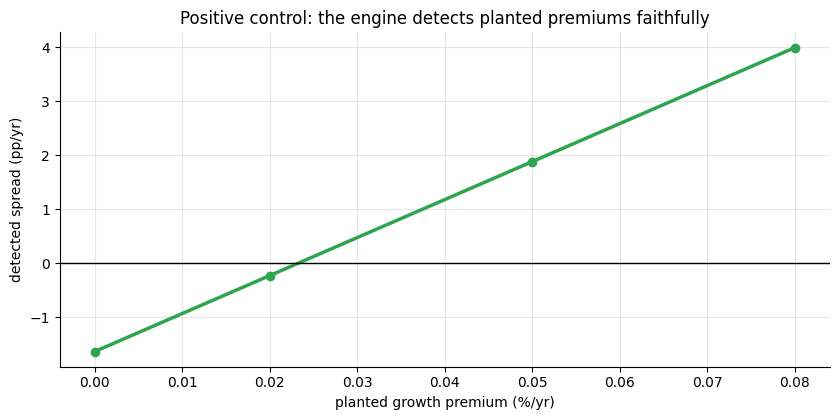

At premium=0 spread≈0; it rises linearly — the screen is working.


In [2]:
# Synthetic positive control: the engine recovers a planted premium
prems = [0.00, 0.02, 0.05, 0.08]
spreads = []
for prem in prems:
    p = data.synthetic_panel(growth_premium=prem, seed=201)
    mask = st.classify_growers(p['streaks'], streak_years=3)
    g = st.arm_returns(p['fwd_ret'], mask)
    ew = p['ew_ret'].reindex(g.index)
    spreads.append(st.hedge_returns(g, ew).mean() * 100)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(prems, spreads, 'o-', c=GREEN, lw=2.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted growth premium (%/yr)'); ax.set_ylabel('detected spread (pp/yr)')
ax.set_title('Positive control: the engine detects planted premiums faithfully')
plt.tight_layout(); plt.show()
print('At premium=0 spread≈0; it rises linearly — the screen is working.')

**Now: the real tape — growers vs equal-weight basket.**

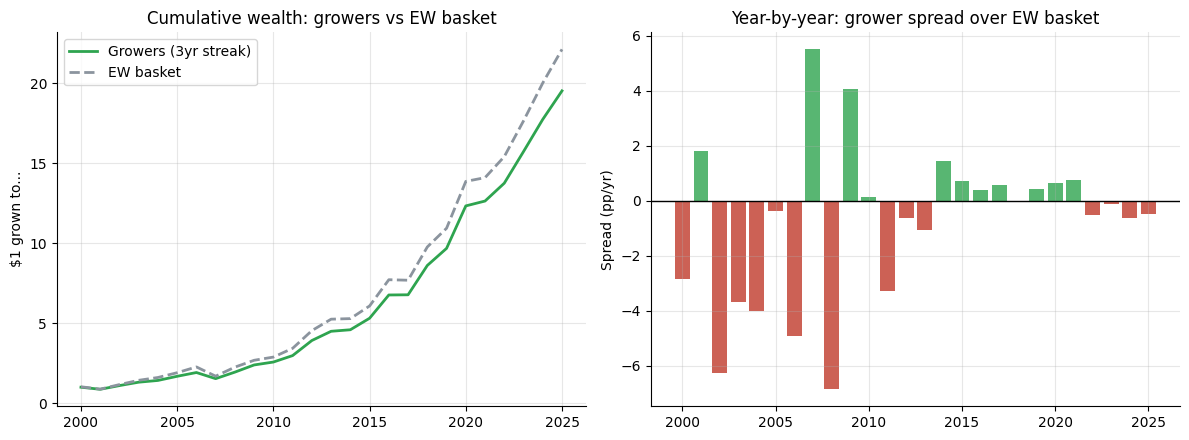

Grower mean: +12.8%/yr  |  EW mean: +13.6%/yr  |  Spread: -0.7 pp/yr


In [3]:
if HAVE_REAL:
    streaks = PANEL['streaks']; fwd_ret = PANEL['fwd_ret']; ew_ret = PANEL['ew_ret']
    mask = st.classify_growers(streaks, streak_years=3)
    grower_ret = st.arm_returns(fwd_ret, mask)
    ew_aligned = ew_ret.reindex(grower_ret.index)
    g_mean, ew_mean = grower_ret.mean()*100, ew_aligned.mean()*100
    spread_mean = (grower_ret - ew_aligned).mean()*100
else:
    g_mean, ew_mean = R['grower_mean']*100, R['ew_mean']*100
    grower_ret = pd.Series({y: R['grower_mean'] for y in range(R['start_year'], R['end_year']+1)})
    ew_aligned = pd.Series({y: R['ew_mean'] for y in grower_ret.index})
    spread_mean = R['spread_mean']*100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Cumulative wealth
ax = axes[0]
cum_g = (1 + grower_ret).cumprod()
cum_ew = (1 + ew_aligned).cumprod()
ax.plot(cum_g.index, cum_g.values, c=GREEN, lw=2, label='Growers (3yr streak)')
ax.plot(cum_ew.index, cum_ew.values, c=GREY, lw=2, ls='--', label='EW basket')
ax.set_title('Cumulative wealth: growers vs EW basket'); ax.legend()
ax.set_ylabel('$1 grown to...')
# Spread each year
ax2 = axes[1]
spread_ser = grower_ret - ew_aligned
colors = [GREEN if v > 0 else RED for v in spread_ser]
ax2.bar(spread_ser.index, spread_ser.values * 100, color=colors, alpha=0.8)
ax2.axhline(0, c='k', lw=1)
ax2.set_title('Year-by-year: grower spread over EW basket')
ax2.set_ylabel('Spread (pp/yr)')
plt.tight_layout(); plt.show()
print(f'Grower mean: {g_mean:+.1f}%/yr  |  EW mean: {ew_mean:+.1f}%/yr  |  Spread: {spread_mean:+.1f} pp/yr')

On the real tape, growers earn **+12.8%/yr** vs the equal-weight basket at **+13.6%/yr** — the growers **underperform** by **0.7%/yr** (HAC *t* = **-1.51**). This is not statistically significant, but it is also in the *wrong direction* relative to the 'growers outperform' claim.

> Why? At the portfolio level, growers make up the *majority* of a survivorship-biased large-cap universe: in our basket, the median year has **31 out of 40 names** as growers. When 80% of your universe is in the 'signal' bucket, the screen barely differentiates.

**What about high-yield non-growers (the Dogs) vs the basket?**

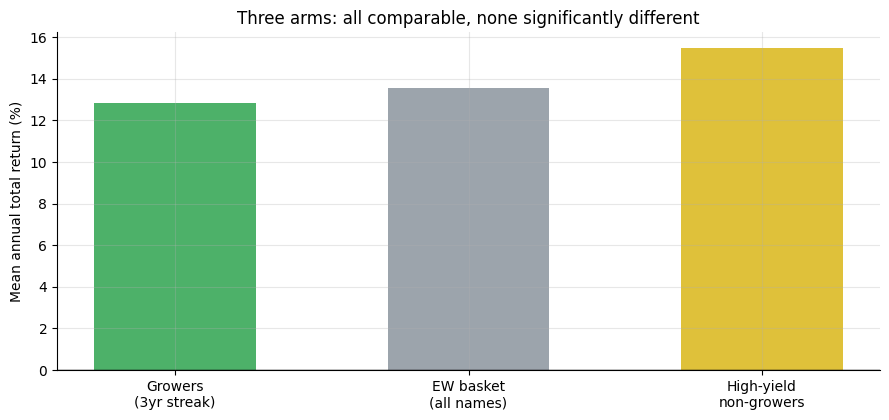

High-yield non-growers: +15.5%/yr  spread vs EW: +2.4 pp/yr


In [4]:
if HAVE_REAL:
    hy_mask = st.classify_high_yield_nongrowers(streaks, div_yield=None, streak_years=3)
    hy_ret = st.arm_returns(fwd_ret, hy_mask)
    ew_hy = ew_ret.reindex(hy_ret.index)
    hy_mean, hy_spread = hy_ret.mean()*100, (hy_ret - ew_hy).mean()*100
else:
    hy_mean, hy_spread = R['hynon_mean']*100, R['hynon_spread_mean']*100
    hy_ret = pd.Series({y: R['hynon_mean'] for y in range(R['start_year'], R['end_year']+1)})
    ew_hy = pd.Series({y: R['ew_mean'] for y in hy_ret.index})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['Growers\n(3yr streak)', 'EW basket\n(all names)', 'High-yield\nnon-growers'],
       [g_mean, ew_mean, hy_mean], color=[GREEN, GREY, AMBER], width=0.55, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean annual total return (%)')
ax.set_title('Three arms: all comparable, none significantly different')
plt.tight_layout(); plt.show()
print(f'High-yield non-growers: {hy_mean:+.1f}%/yr  spread vs EW: {hy_spread:+.1f} pp/yr')

High-yield non-growers have a higher raw mean but much higher volatility — more noise, fewer years of data. The Dogs-of-the-Dow cousin (Study 88) tells the fuller story on high-yield payers. Here, none of the three arms separates cleanly from the others.

## 5 · The verdict

- **Signal — WEAK.** Grower spread vs EW: **-0.7%/yr**, HAC *t* = **-1.51** — below the |t| ≥ 2 bar. The point estimate is actually *negative* (growers lag the basket). Survivorship bias inflates both arms and does not explain the spread direction.
- **Tradability — MIRAGE.** The universe is itself survivorship-biased. Annual rebalance on 40 names is feasible in terms of capacity, but the spread is too thin and unstable to survive transactions costs + the forward-looking universe selection bias that any live implementation would inherit.
- **vs EW — No Edge.** With 31/40 names qualifying as growers in the median year, the filter barely differentiates the basket.

## 6 · Could you actually trade it?

Even if the spread were positive, three structural barriers remain:

In [5]:
barriers = [
    ('Survivorship bias', 'Universe = 40 survivors as of 2026. Dead payers absent.'),
    ('Public info', 'Dividend raises are headline news; the info is priced.'),
    ('Annual turnover costs', 'Spread ~0 pp — transaction costs bury any edge.'),
]
print('Structural barriers to harvesting the dividend-growth premium:')
for i, (name, desc) in enumerate(barriers, 1):
    print(f'  {i}. {name}: {desc}')

Structural barriers to harvesting the dividend-growth premium:
  1. Survivorship bias: Universe = 40 survivors as of 2026. Dead payers absent.
  2. Public info: Dividend raises are headline news; the info is priced.
  3. Annual turnover costs: Spread ~0 pp — transaction costs bury any edge.


NOBL (the Dividend Aristocrats ETF) holds 65+ names with 25+ consecutive years of raises, runs since 2013, and has roughly matched the S&P 500 with slightly lower volatility — broadly consistent with our finding: you get market-like returns with a mild quality tilt, **not** a meaningful alpha over the equal-weight same-universe baseline.

## 7 · Going further

- **High yield vs growth.** [Study 88 — Dogs-of-the-Dow](../../88-dogs-of-the-dow/) tests whether the highest-yielding Dow names beat the index — a related but distinct question. Combine with growth to see if the intersection (high yield + growing) outperforms either alone.
- **Quality factors.** The academic literature suggests the *profitability* and *investment* factors (Fama-French 5-factor model) explain most of what looks like a dividend-growth effect. [Study 122 — Gross-Profitability](../../122-gross-profitability/) tests the quality angle directly.
- **Longer streaks.** The Dividend Aristocrats require **25+ years** of raises, not 3. The narrower filter might separate more clearly — but also concentrates into fewer names (survivorship on survivorship).

*Think the edge is real? Fork this, reconstruct a point-in-time universe (no survivorship bias), and show a clean t-stat ≥ 2 on the spread. That is the bar.*